In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Sensor Logs- Already in IST

In [18]:
logs = pd.read_json('gursimar_system_logs.jsonl', lines = True)

In [19]:
logs["timestamp"] = pd.to_datetime(logs["timestamp"]).dt.tz_localize("Asia/Kolkata")

In [20]:
logs.head()     # This is in IST Format only

,timestamp,cpuUsage,cpuTemperature,cpuPackagePower,cpuVoltageCore1,cpuAverageClock,cpuEfficiencyAverageClock,cpuFactors,virtualMemoryUsage,totalMemoryUsage,...,gpuHotspotTemperature,gpuCoreLoad,gpuCoreVoltage,gpuPackagePower,gpuCoreClock,gpuMemoryClock,gpuMemoryLoad,ssdCompositeTemperature,networkConnections,processCount
0,2026-07-14 00:04:49.443029400+05:30,52.2,85.0,35.2,1.29,3988,2188,"[39.75, 40.0, 40.0, 40.0, 40.0, 40.0]",71.2,94.1,...,68.3,0,0.6,1.6,300,405,5.4,61,129,252
1,2026-07-14 00:04:52.428620+05:30,14.5,81.4,16.3,1.29,3622,553,"[40.0, 40.0, 17.78, 40.0, 40.0, 40.0]",71.6,88.5,...,68.4,0,0.6,1.9,300,405,5.4,62,132,252
2,2026-07-14 00:04:54.511002500+05:30,17.5,79.3,19.0,1.23,3992,857,"[40.0, 40.0, 40.0, 40.0, 40.0, 40.0]",71.6,88.7,...,68.2,0,0.6,1.7,300,405,5.4,62,133,252
3,2026-07-14 00:04:56.576751700+05:30,7.2,76.5,9.4,0.81,2554,216,"[14.0, 14.0, 40.0, 40.0, 17.78, 40.0]",71.6,89.0,...,68.1,0,0.6,1.7,300,405,5.4,62,133,251
4,2026-07-14 00:04:58.626523500+05:30,5.7,73.5,9.9,0.74,2664,235,"[17.78, 40.0, 40.0, 14.0, 17.78, 40.0]",71.6,89.1,...,67.8,0,0.6,1.6,300,405,5.4,63,133,251


# Load Stress Events - UTC Format (Z)

In [21]:
events = pd.read_json("gursimar_stress_events.jsonl", lines = True)

In [22]:
events["startTime"] = pd.to_datetime(events["startTime"], utc= True).dt.tz_convert("Asia/Kolkata")
events["endTime"] = pd.to_datetime(events["endTime"], utc= True).dt.tz_convert("Asia/Kolkata")


In [23]:
events.head()

,eventType,runId,deviceId,mode,targetLoad,gpuTargetLoad,stepNumber,startTime,endTime,actualDurationSeconds,seed,message
0,RUN_START,Gursimar_2026-07-13T18-36-17-302642900Z,Gursimar,SYSTEM,0,-1,0,2026-07-14 00:06:19.517063900+05:30,2026-07-14 00:06:19.517063900+05:30,0,101,Automatic stress experiment started.
1,SESSION,Gursimar_2026-07-13T18-36-17-302642900Z,Gursimar,INITIAL_IDLE,0,-1,0,2026-07-14 00:06:19.524064+05:30,2026-07-14 00:08:19.526128700+05:30,120,101,Idle or cooling session completed.
2,WORKLOAD_STEP,Gursimar_2026-07-13T18-36-17-302642900Z,Gursimar,RAMP,0,-1,1,2026-07-14 00:08:19.529912900+05:30,2026-07-14 00:09:38.530929400+05:30,79,101,Completed workload step.
3,WORKLOAD_STEP,Gursimar_2026-07-13T18-36-17-302642900Z,Gursimar,RAMP,0,-1,2,2026-07-14 00:09:38.531971800+05:30,2026-07-14 00:10:44.533889600+05:30,66,101,Completed workload step.
4,WORKLOAD_STEP,Gursimar_2026-07-13T18-36-17-302642900Z,Gursimar,RAMP,20,-1,3,2026-07-14 00:10:44.534705600+05:30,2026-07-14 00:14:35.548965900+05:30,231,101,Completed workload step.


In [24]:
logs["timestamp"] = pd.to_datetime(logs["timestamp"])

events["startTime"] = pd.to_datetime(events["startTime"])
events["endTime"] = pd.to_datetime(events["endTime"])


In [25]:
logs = logs.sort_values("timestamp").reset_index(drop=True)
events = events.sort_values("startTime").reset_index(drop=True)

In [26]:
logs.head()

,timestamp,cpuUsage,cpuTemperature,cpuPackagePower,cpuVoltageCore1,cpuAverageClock,cpuEfficiencyAverageClock,cpuFactors,virtualMemoryUsage,totalMemoryUsage,...,gpuHotspotTemperature,gpuCoreLoad,gpuCoreVoltage,gpuPackagePower,gpuCoreClock,gpuMemoryClock,gpuMemoryLoad,ssdCompositeTemperature,networkConnections,processCount
0,2026-07-14 00:04:49.443029400+05:30,52.2,85.0,35.2,1.29,3988,2188,"[39.75, 40.0, 40.0, 40.0, 40.0, 40.0]",71.2,94.1,...,68.3,0,0.6,1.6,300,405,5.4,61,129,252
1,2026-07-14 00:04:52.428620+05:30,14.5,81.4,16.3,1.29,3622,553,"[40.0, 40.0, 17.78, 40.0, 40.0, 40.0]",71.6,88.5,...,68.4,0,0.6,1.9,300,405,5.4,62,132,252
2,2026-07-14 00:04:54.511002500+05:30,17.5,79.3,19.0,1.23,3992,857,"[40.0, 40.0, 40.0, 40.0, 40.0, 40.0]",71.6,88.7,...,68.2,0,0.6,1.7,300,405,5.4,62,133,252
3,2026-07-14 00:04:56.576751700+05:30,7.2,76.5,9.4,0.81,2554,216,"[14.0, 14.0, 40.0, 40.0, 17.78, 40.0]",71.6,89.0,...,68.1,0,0.6,1.7,300,405,5.4,62,133,251
4,2026-07-14 00:04:58.626523500+05:30,5.7,73.5,9.9,0.74,2664,235,"[17.78, 40.0, 40.0, 14.0, 17.78, 40.0]",71.6,89.1,...,67.8,0,0.6,1.6,300,405,5.4,63,133,251


In [27]:
events.head()

,eventType,runId,deviceId,mode,targetLoad,gpuTargetLoad,stepNumber,startTime,endTime,actualDurationSeconds,seed,message
0,RUN_START,Gursimar_2026-07-13T18-36-17-302642900Z,Gursimar,SYSTEM,0,-1,0,2026-07-14 00:06:19.517063900+05:30,2026-07-14 00:06:19.517063900+05:30,0,101,Automatic stress experiment started.
1,RUN,Gursimar_2026-07-13T18-36-17-302642900Z,Gursimar,COMPLETE_EXPERIMENT,0,-1,0,2026-07-14 00:06:19.517063900+05:30,2026-07-14 08:18:19.764692+05:30,29520,101,Experiment completed normally.
2,SESSION,Gursimar_2026-07-13T18-36-17-302642900Z,Gursimar,INITIAL_IDLE,0,-1,0,2026-07-14 00:06:19.524064+05:30,2026-07-14 00:08:19.526128700+05:30,120,101,Idle or cooling session completed.
3,SESSION,Gursimar_2026-07-13T18-36-17-302642900Z,Gursimar,RAMP,0,-1,51,2026-07-14 00:08:19.527912600+05:30,2026-07-14 01:22:19.541374900+05:30,4440,101,Workload session completed.
4,WORKLOAD_STEP,Gursimar_2026-07-13T18-36-17-302642900Z,Gursimar,RAMP,0,-1,1,2026-07-14 00:08:19.529912900+05:30,2026-07-14 00:09:38.530929400+05:30,79,101,Completed workload step.


In [28]:
print("Sensor start:", logs["timestamp"].min())
print("Sensor end:  ", logs["timestamp"].max())


Sensor start: 2026-07-14 00:04:49.443029400+05:30
Sensor end:   2026-07-14 08:19:28.844136300+05:30


In [29]:
print("\nEvent start:", events["startTime"].min())
print("Event end:  ", events["endTime"].max())


Event start: 2026-07-14 00:06:19.517063900+05:30
Event end:   2026-07-14 08:18:19.764692+05:30


In [30]:
print("Sensor timezone:", logs["timestamp"].dt.tz)
print("Event timezone:", events["startTime"].dt.tz)

Sensor timezone: Asia/Kolkata
Event timezone: Asia/Kolkata


In [31]:
print(events.head(10).to_string())

print("\nUnique event types:")
if "eventType" in events.columns:
    print(events["eventType"].value_counts())

print("\nUnique modes:")
if "mode" in events.columns:
    print(events["mode"].value_counts())

       eventType                                    runId  deviceId                 mode  targetLoad  gpuTargetLoad  stepNumber                           startTime                             endTime  actualDurationSeconds  seed                               message
0      RUN_START  Gursimar_2026-07-13T18-36-17-302642900Z  Gursimar               SYSTEM           0             -1           0 2026-07-14 00:06:19.517063900+05:30 2026-07-14 00:06:19.517063900+05:30                      0   101  Automatic stress experiment started.
1            RUN  Gursimar_2026-07-13T18-36-17-302642900Z  Gursimar  COMPLETE_EXPERIMENT           0             -1           0 2026-07-14 00:06:19.517063900+05:30    2026-07-14 08:18:19.764692+05:30                  29520   101        Experiment completed normally.
2        SESSION  Gursimar_2026-07-13T18-36-17-302642900Z  Gursimar         INITIAL_IDLE           0             -1           0    2026-07-14 00:06:19.524064+05:30 2026-07-14 00:08:19.526128700+05:30

# Cleaning the Stress Intervals

In [32]:
# Keep events that have a valid time interval
intervals = events[
    events["startTime"].notna() &
    events["endTime"].notna()
].copy()

# Remove invalid intervals
intervals = intervals[
    intervals["endTime"] > intervals["startTime"]
].copy()
intervals = intervals.sort_values("startTime").reset_index(drop=True)
print("Usable intervals:", len(intervals))

display(
    intervals[
        [
            col for col in [
                "startTime",
                "endTime",
                "mode",
                "targetLoad",
                "stepNumber",
                "eventType"
            ]
            if col in intervals.columns
        ]
    ].head(20)
)


Usable intervals: 304


,startTime,endTime,mode,targetLoad,stepNumber,eventType
0,2026-07-14 00:06:19.517063900+05:30,2026-07-14 08:18:19.764692+05:30,COMPLETE_EXPERIMENT,0,0,RUN
1,2026-07-14 00:06:19.524064+05:30,2026-07-14 00:08:19.526128700+05:30,INITIAL_IDLE,0,0,SESSION
2,2026-07-14 00:08:19.527912600+05:30,2026-07-14 01:22:19.541374900+05:30,RAMP,0,51,SESSION
3,2026-07-14 00:08:19.529912900+05:30,2026-07-14 00:09:38.530929400+05:30,RAMP,0,1,WORKLOAD_STEP
4,2026-07-14 00:09:38.531971800+05:30,2026-07-14 00:10:44.533889600+05:30,RAMP,0,2,WORKLOAD_STEP
5,2026-07-14 00:10:44.534705600+05:30,2026-07-14 00:14:35.548965900+05:30,RAMP,20,3,WORKLOAD_STEP
6,2026-07-14 00:14:35.549965800+05:30,2026-07-14 00:15:13.551712500+05:30,RAMP,20,4,WORKLOAD_STEP
7,2026-07-14 00:15:13.552717500+05:30,2026-07-14 00:18:28.554763500+05:30,RAMP,40,5,WORKLOAD_STEP
8,2026-07-14 00:18:28.555773700+05:30,2026-07-14 00:20:53.557524600+05:30,RAMP,40,6,WORKLOAD_STEP
9,2026-07-14 00:20:53.558533500+05:30,2026-07-14 00:21:21.559868600+05:30,RAMP,60,7,WORKLOAD_STEP


In [33]:
# ============================================================
# BUILD CLEAN INTERVAL TABLES
# ============================================================

# Detailed workload intervals
workload_steps = events[
    events["eventType"] == "WORKLOAD_STEP"
].copy()

# Idle and cooling intervals
session_intervals = events[
    (events["eventType"] == "SESSION") &
    (
        (events["mode"] == "INITIAL_IDLE") |
        (events["mode"].str.contains("COOLING", na=False))
    )
].copy()


print("Workload steps:", len(workload_steps))
print("Idle/cooling sessions:", len(session_intervals))

print("\nWorkload modes:")
print(workload_steps["mode"].value_counts())

print("\nNon-workload sessions:")
print(session_intervals["mode"].value_counts())

Workload steps: 286
Idle/cooling sessions: 9

Workload modes:
mode
MIXED               98
RAMP                51
GPU_CPU_COMBINED    49
TRANSITION          49
CHAOS               39
Name: count, dtype: int64

Non-workload sessions:
mode
INITIAL_IDLE                        1
COOLING_AFTER_RAMP                  1
COOLING_AFTER_GPU_CPU_COMBINED_1    1
COOLING_AFTER_CHAOS                 1
COOLING_AFTER_GPU_CPU_COMBINED_2    1
COOLING_AFTER_TRANSITION            1
COOLING_AFTER_GPU_CPU_COMBINED_3    1
COOLING_AFTER_MIXED                 1
FINAL_COOLING                       1
Name: count, dtype: int64


In [34]:
import numpy as np

In [35]:
merged = logs.copy()

merged["mode"] = "UNASSIGNED"
merged["targetLoad"] = np.nan
merged["gpuTargetLoad"] = np.nan
merged["stepNumber"] = np.nan
merged["eventType"] = None


# ===============
# =============================================
# 1. ASSIGN IDLE AND COOLING SESSIONS
# ============================================================

for _, event in session_intervals.iterrows():

    mask = (
        (merged["timestamp"] >= event["startTime"]) &
        (merged["timestamp"] < event["endTime"])
    )

    merged.loc[mask, "mode"] = event["mode"]
    merged.loc[mask, "targetLoad"] = 0
    merged.loc[mask, "gpuTargetLoad"] = np.nan
    merged.loc[mask, "eventType"] = "SESSION"


# ============================================================
# 2. ASSIGN ACTUAL WORKLOAD STEPS
# ============================================================

for _, event in workload_steps.iterrows():

    mask = (
        (merged["timestamp"] >= event["startTime"]) &
        (merged["timestamp"] < event["endTime"])
    )

    merged.loc[mask, "mode"] = event["mode"]
    merged.loc[mask, "targetLoad"] = event["targetLoad"]
    merged.loc[mask, "gpuTargetLoad"] = event["gpuTargetLoad"]
    merged.loc[mask, "stepNumber"] = event["stepNumber"]
    merged.loc[mask, "eventType"] = "WORKLOAD_STEP"


# ============================================================
# 3. IMPUTE ZERO TEMPERATURE READINGS
# ============================================================

zero_temp_mask = merged["cpuTemperature"] == 0
zero_temp_count = int(zero_temp_mask.sum())

if zero_temp_count > 0:
    merged.loc[zero_temp_mask, "cpuTemperature"] = np.nan
    merged["cpuTemperature"] = (
        merged["cpuTemperature"]
        .interpolate(method="linear")
        .ffill()
        .bfill()
    )
    print(f"Imputed {zero_temp_count} zero-temperature rows.")


In [36]:
print("Merged shape:", merged.shape)

print("\nMode distribution:")
print(merged["mode"].value_counts())

print("\nEvent type distribution:")
print(merged["eventType"].value_counts(dropna=False))

print("\nUnassigned samples:")
print((merged["mode"] == "UNASSIGNED").sum())

Merged shape: (14621, 28)

Mode distribution:
mode
MIXED                               4378
GPU_CPU_COMBINED                    2213
CHAOS                               2188
TRANSITION                          2186
RAMP                                2184
FINAL_COOLING                        297
COOLING_AFTER_CHAOS                  149
COOLING_AFTER_RAMP                   148
COOLING_AFTER_GPU_CPU_COMBINED_1     148
COOLING_AFTER_GPU_CPU_COMBINED_2     148
COOLING_AFTER_TRANSITION             148
COOLING_AFTER_GPU_CPU_COMBINED_3     148
COOLING_AFTER_MIXED                  148
UNASSIGNED                            79
INITIAL_IDLE                          59
Name: count, dtype: int64

Event type distribution:
eventType
WORKLOAD_STEP    13149
SESSION           1393
None                79
Name: count, dtype: int64

Unassigned samples:
79


In [37]:
# experiment_start = events.loc[
#     events["eventType"] == "RUN",
#     "startTime"
# ].iloc[0]

# experiment_end = events.loc[
#     events["eventType"] == "RUN",
#     "endTime"
# ].iloc[0]


# merged.loc[
#     merged["timestamp"] < experiment_start,
#     "mode"
# ] = "PRE_EXPERIMENT"


# merged.loc[
#     merged["timestamp"] >= experiment_end,
#     "mode"
# ] = "POST_EXPERIMENT"

In [38]:
merged.to_csv(
    "gursimar_merged_experiment.csv",
    index=False
)

print("Saved: gursimar_merged_experiment.csv")

Saved: gursimar_merged_experiment.csv


In [39]:
import matplotlib.pyplot as plt

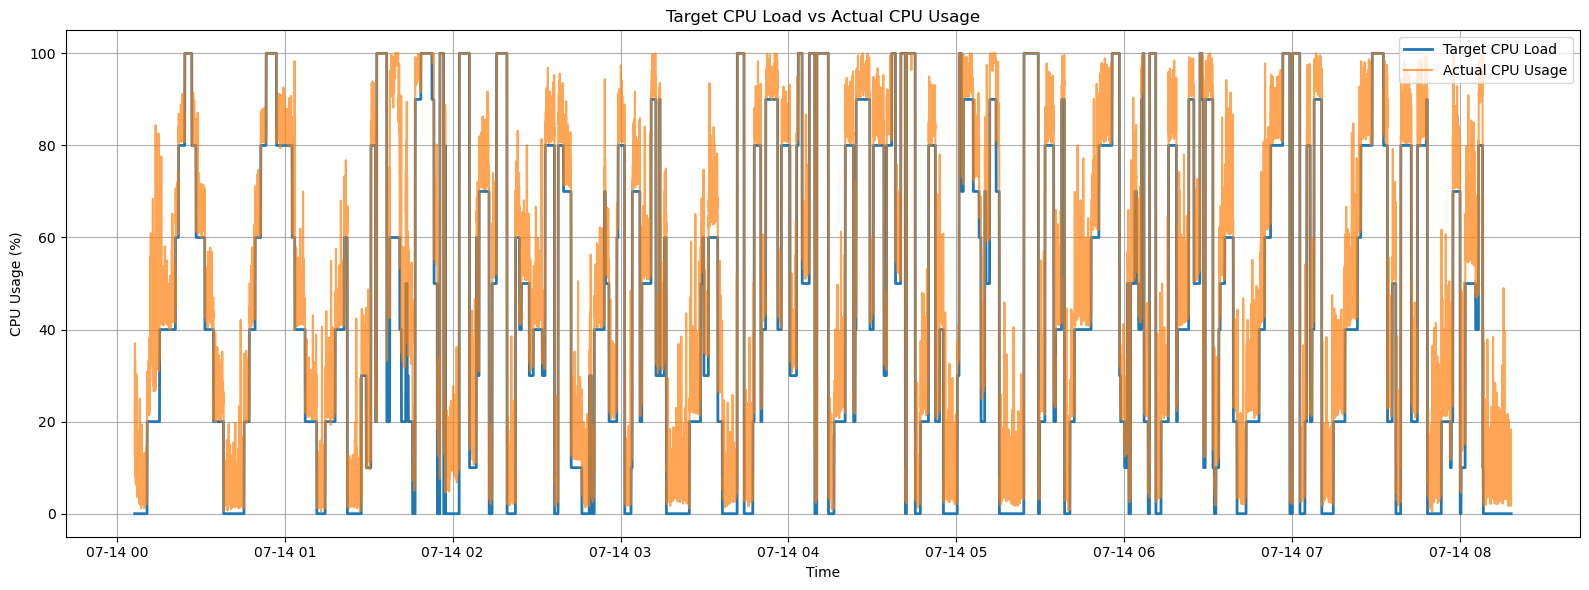

In [40]:
valid_target = merged.dropna(
    subset=["targetLoad", "cpuUsage"]
).copy()

plt.figure(figsize=(16, 6))

plt.plot(
    valid_target["timestamp"],
    valid_target["targetLoad"],
    label="Target CPU Load",
    linewidth=2
)

plt.plot(
    valid_target["timestamp"],
    valid_target["cpuUsage"],
    label="Actual CPU Usage",
    alpha=0.7
)

plt.title("Target CPU Load vs Actual CPU Usage")
plt.xlabel("Time")
plt.ylabel("CPU Usage (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [41]:
valid_target["loadError"] = (
    valid_target["cpuUsage"] -
    valid_target["targetLoad"]
)

print(
    "Mean Absolute Load Error:",
    valid_target["loadError"].abs().mean()
)

print(
    "Correlation:",
    valid_target[
        ["targetLoad", "cpuUsage"]
    ].corr().iloc[0, 1]
)

Mean Absolute Load Error: 6.144388667308486
Correlation: 0.9741278058339895


In [42]:
load_summary = (
    valid_target
    .groupby("targetLoad")
    .agg(
        samples=("cpuUsage", "count"),
        meanActualCPU=("cpuUsage", "mean"),
        stdActualCPU=("cpuUsage", "std"),
        meanTemperature=("cpuTemperature", "mean")
    )
    .reset_index()
)

display(load_summary)

,targetLoad,samples,meanActualCPU,stdActualCPU,meanTemperature
0,0.0,3185,7.717111,8.514925,60.887190
1,10.0,400,17.945250,8.682482,70.419250
2,20.0,2120,28.255047,9.305015,79.834953
3,30.0,427,37.296253,7.996404,81.491803
4,40.0,1576,45.751840,6.500012,88.338198
5,50.0,847,57.179693,7.661985,89.900118
6,60.0,850,69.042118,11.525211,93.751647
7,70.0,506,75.755929,5.250838,92.112451
8,80.0,2010,84.383632,5.006195,94.695572
9,90.0,880,93.881705,3.631814,95.023523


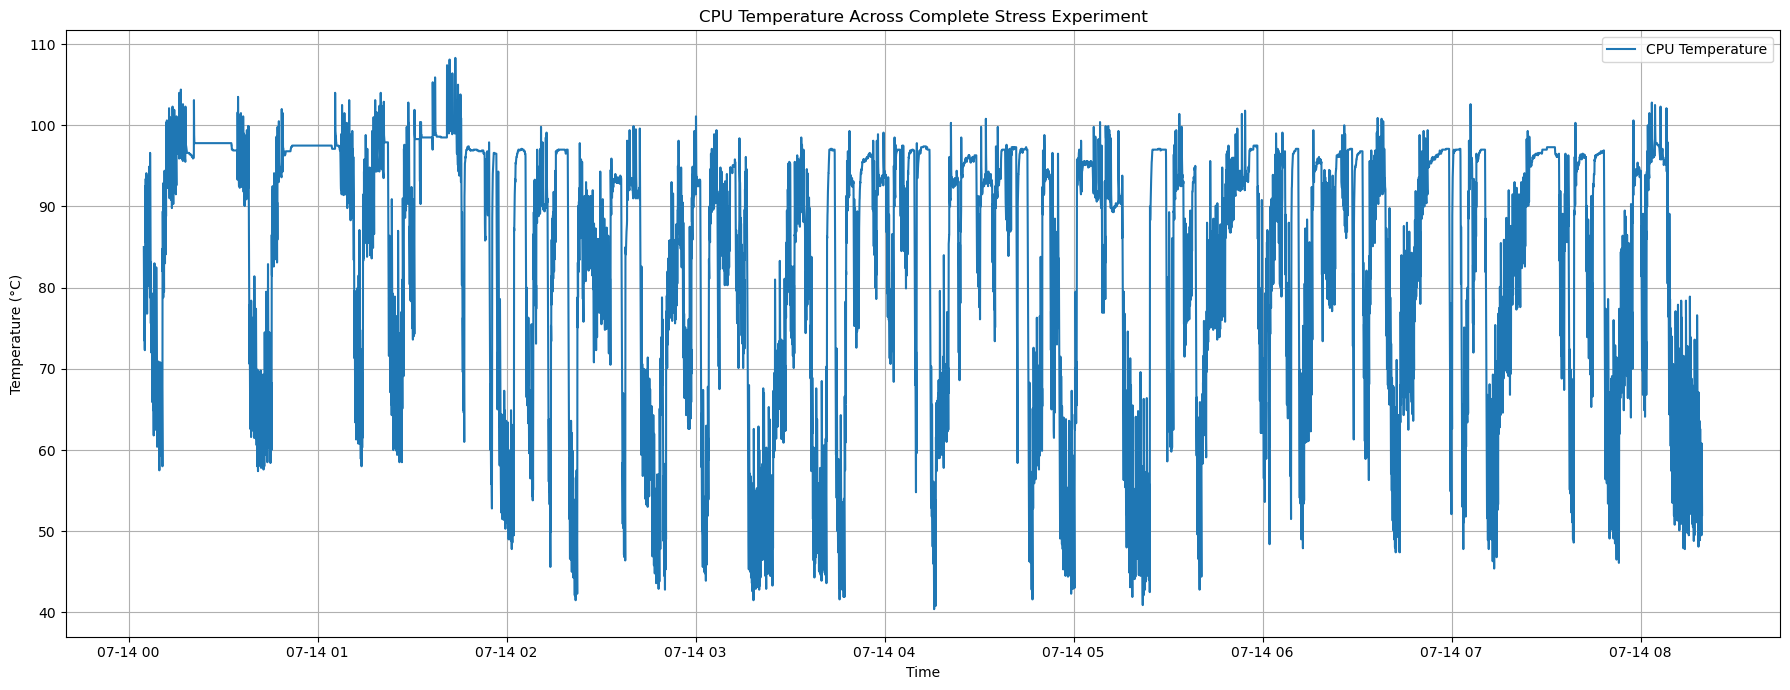

In [43]:
plt.figure(figsize=(18, 7))

plt.plot(
    merged["timestamp"],
    merged["cpuTemperature"],
    label="CPU Temperature"
)

plt.title(
    "CPU Temperature Across Complete Stress Experiment"
)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [44]:
mode_changes = merged[
    merged["mode"] != merged["mode"].shift()
][
    ["timestamp", "mode"]
]

display(mode_changes)

,timestamp,mode
0,2026-07-14 00:04:49.443029400+05:30,UNASSIGNED
44,2026-07-14 00:06:20.660973800+05:30,INITIAL_IDLE
103,2026-07-14 00:08:20.342648600+05:30,RAMP
2287,2026-07-14 01:22:19.608562700+05:30,COOLING_AFTER_RAMP
2435,2026-07-14 01:27:19.943717100+05:30,GPU_CPU_COMBINED
3315,2026-07-14 01:57:20.494091800+05:30,COOLING_AFTER_GPU_CPU_COMBINED_1
3463,2026-07-14 02:02:19.878965200+05:30,CHAOS
5651,2026-07-14 03:16:19.946725600+05:30,COOLING_AFTER_CHAOS
5800,2026-07-14 03:21:21.250578600+05:30,GPU_CPU_COMBINED
6245,2026-07-14 03:36:21.247459700+05:30,COOLING_AFTER_GPU_CPU_COMBINED_2


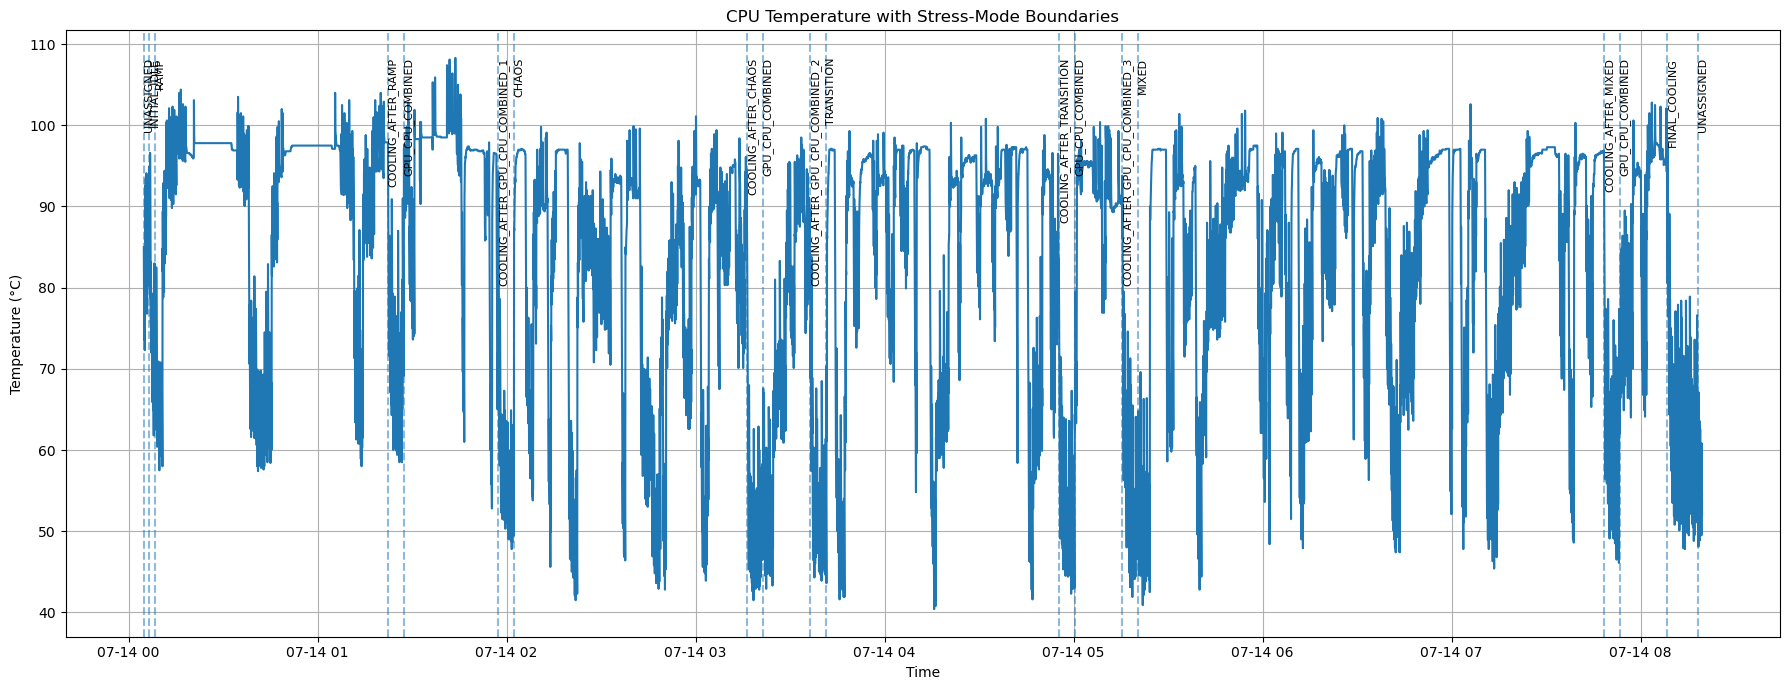

In [45]:
plt.figure(figsize=(18, 7))

plt.plot(
    merged["timestamp"],
    merged["cpuTemperature"],
    label="CPU Temperature"
)

for _, row in mode_changes.iterrows():

    plt.axvline(
        row["timestamp"],
        linestyle="--",
        alpha=0.5
    )

    plt.text(
        row["timestamp"],
        merged["cpuTemperature"].max(),
        str(row["mode"]),
        rotation=90,
        verticalalignment="top",
        fontsize=8
    )

plt.title(
    "CPU Temperature with Stress-Mode Boundaries"
)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")

plt.grid(True)
plt.tight_layout()
plt.show()

In [46]:
# Correlate every numeric sensor and workload target with both temperatures.
# Pearson captures linear relationships; Spearman captures monotonic ones.
temperature_targets = ["cpuTemperature", "gpuTemperature"]
numeric_features = merged.select_dtypes(include="number").columns.tolist()
feature_columns = [
    col for col in numeric_features
    if col not in temperature_targets + ["stepNumber"]
]

pearson_correlations = merged[feature_columns + temperature_targets].corr(method="pearson")
spearman_correlations = merged[feature_columns + temperature_targets].corr(method="spearman")

correlation_summary = (
    pd.DataFrame({
        "pearson_cpuTemperature": pearson_correlations["cpuTemperature"].drop("cpuTemperature"),
        "spearman_cpuTemperature": spearman_correlations["cpuTemperature"].drop("cpuTemperature"),
        "pearson_gpuTemperature": pearson_correlations["gpuTemperature"].drop("gpuTemperature"),
        "spearman_gpuTemperature": spearman_correlations["gpuTemperature"].drop("gpuTemperature"),
    })
    .drop(index=["gpuTemperature", "cpuTemperature"], errors="ignore")
)
correlation_summary["max_abs_pearson"] = correlation_summary[
    ["pearson_cpuTemperature", "pearson_gpuTemperature"]
].abs().max(axis=1)
correlation_summary = correlation_summary.sort_values("max_abs_pearson", ascending=False)

display(correlation_summary.round(3))

# Dedicated efficiency-clock correlations requested for CPU frequency analysis.
efficiency_clock_pairs = [
    ("cpuEfficiencyAverageClock", "cpuAverageClock", "Average CPU Clock"),
    ("cpuEfficiencyAverageClock", "cpuVoltageCore1", "CPU Core 1 Voltage"),
]
efficiency_clock_correlation = pd.DataFrame([
    {
        "feature": label,
        "pearsonCorrelation": merged[[efficiency_col, feature_col]].corr(method="pearson").iloc[0, 1],
        "spearmanCorrelation": merged[[efficiency_col, feature_col]].corr(method="spearman").iloc[0, 1],
    }
    for efficiency_col, feature_col, label in efficiency_clock_pairs
])
display(efficiency_clock_correlation.round(3))


,pearson_cpuTemperature,spearman_cpuTemperature,pearson_gpuTemperature,spearman_gpuTemperature,max_abs_pearson
gpuCoreTemperature,0.647,0.785,1.000,1.000,1.000
gpuHotspotTemperature,0.631,0.783,0.998,0.998,0.998
cpuPackagePower,0.822,0.732,0.259,0.372,0.822
cpuUsage,0.814,0.813,0.386,0.485,0.814
cpuEfficiencyAverageClock,0.812,0.788,0.334,0.448,0.812
targetLoad,0.785,0.789,0.332,0.463,0.785
ssdCompositeTemperature,0.190,0.267,0.654,0.591,0.654
cpuAverageClock,0.596,0.303,0.161,0.108,0.596
processCount,0.209,0.360,0.561,0.573,0.561
gpuPackagePower,0.175,0.484,0.520,0.469,0.520


,feature,pearsonCorrelation,spearmanCorrelation
0,Average CPU Clock,0.621,0.481
1,CPU Core 1 Voltage,0.482,0.469


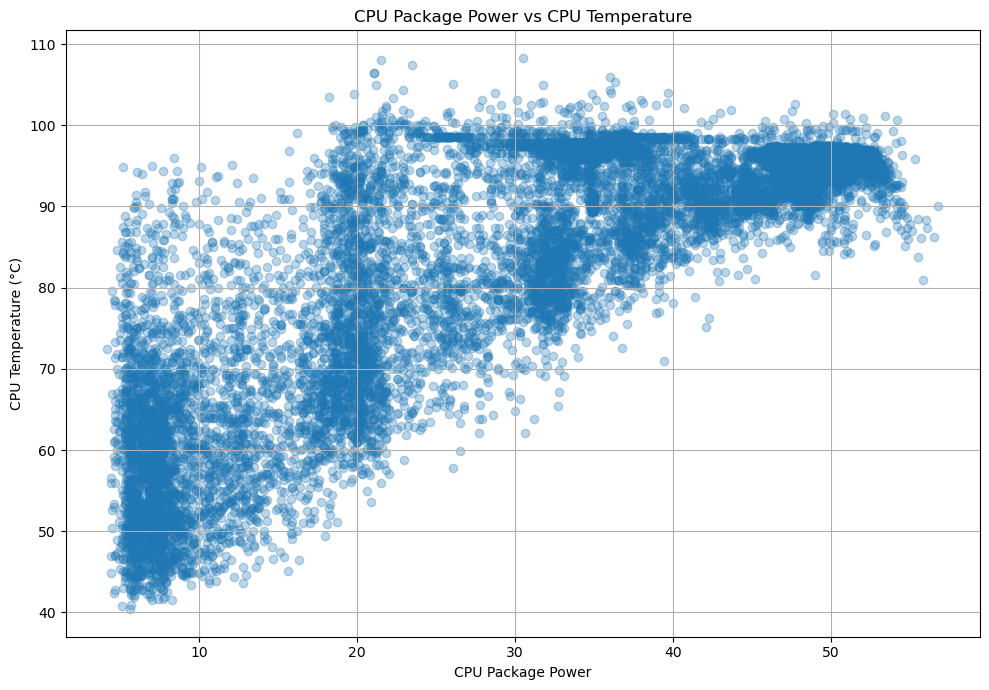

In [47]:
plt.figure(figsize=(10, 7))

plt.scatter(
    merged["cpuPackagePower"],
    merged["cpuTemperature"],
    alpha=0.3
)

plt.title("CPU Package Power vs CPU Temperature")
plt.xlabel("CPU Package Power")
plt.ylabel("CPU Temperature (°C)")
plt.grid(True)
plt.tight_layout()
plt.show()

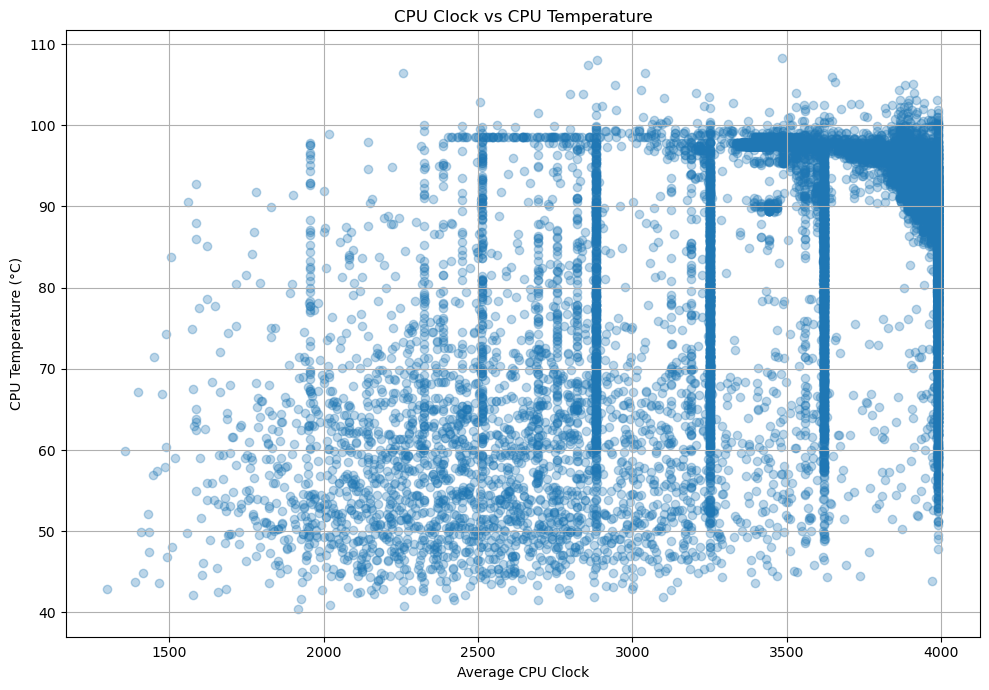

In [48]:
plt.figure(figsize=(10, 7))

plt.scatter(
    merged["cpuAverageClock"],
    merged["cpuTemperature"],
    alpha=0.3
)

plt.title("CPU Clock vs CPU Temperature")
plt.xlabel("Average CPU Clock")
plt.ylabel("CPU Temperature (°C)")
plt.grid(True)
plt.tight_layout()
plt.show()

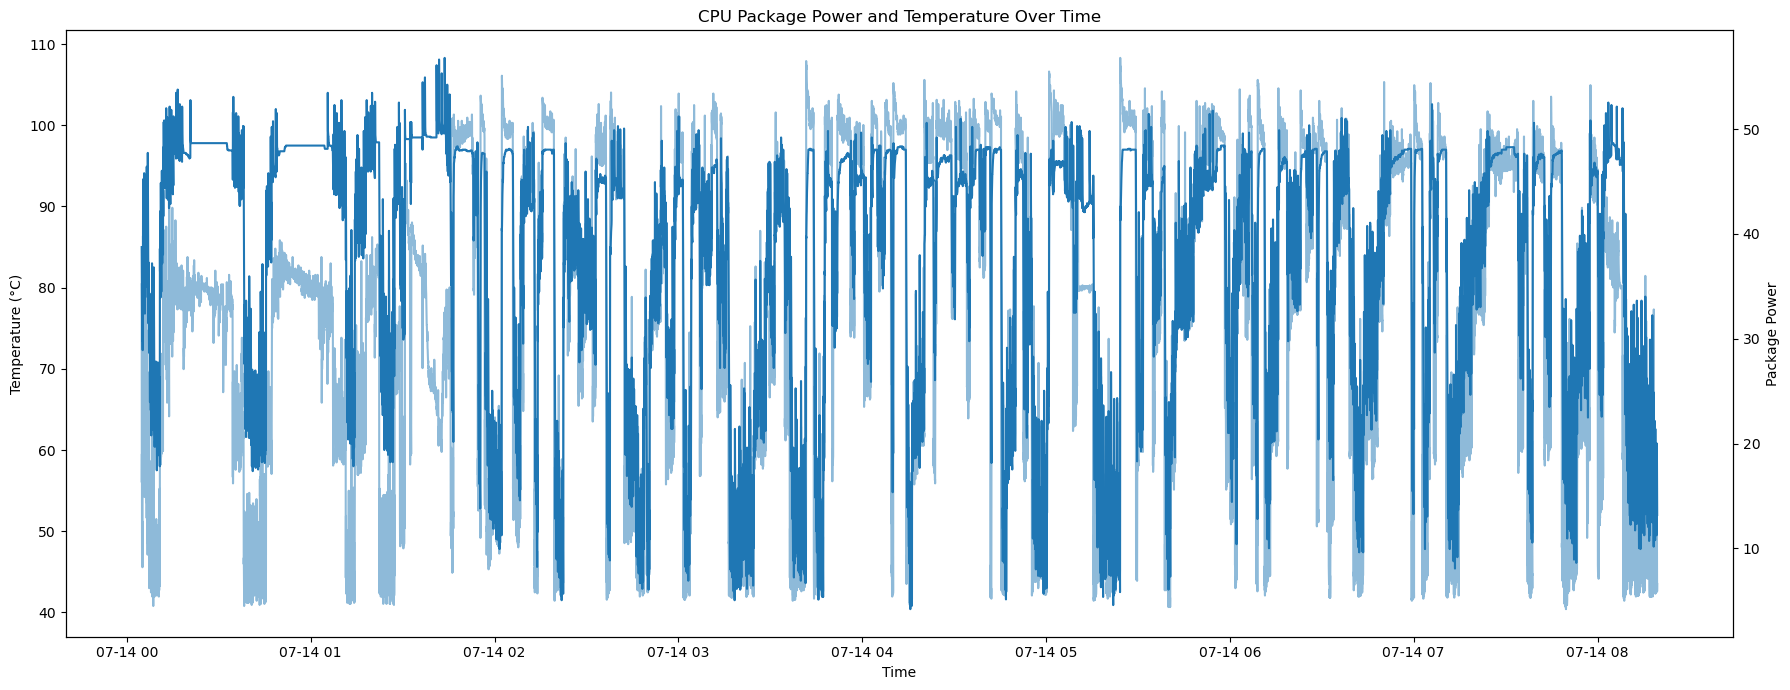

In [49]:
fig, ax1 = plt.subplots(figsize=(18, 7))

ax1.plot(
    merged["timestamp"],
    merged["cpuTemperature"],
    label="Temperature"
)

ax1.set_xlabel("Time")
ax1.set_ylabel("Temperature (°C)")

ax2 = ax1.twinx()

ax2.plot(
    merged["timestamp"],
    merged["cpuPackagePower"],
    alpha=0.5,
    label="Package Power"
)

ax2.set_ylabel("Package Power")

plt.title(
    "CPU Package Power and Temperature Over Time"
)

fig.tight_layout()
plt.show()

In [50]:
cooling = merged[
    merged["mode"]
    .astype(str)
    .str.contains("COOLING", case=False, na=False)
].copy()

print("Cooling samples:", len(cooling))

print(
    cooling["mode"].value_counts()
)

Cooling samples: 1334
mode
FINAL_COOLING                       297
COOLING_AFTER_CHAOS                 149
COOLING_AFTER_RAMP                  148
COOLING_AFTER_GPU_CPU_COMBINED_1    148
COOLING_AFTER_GPU_CPU_COMBINED_2    148
COOLING_AFTER_TRANSITION            148
COOLING_AFTER_GPU_CPU_COMBINED_3    148
COOLING_AFTER_MIXED                 148
Name: count, dtype: int64


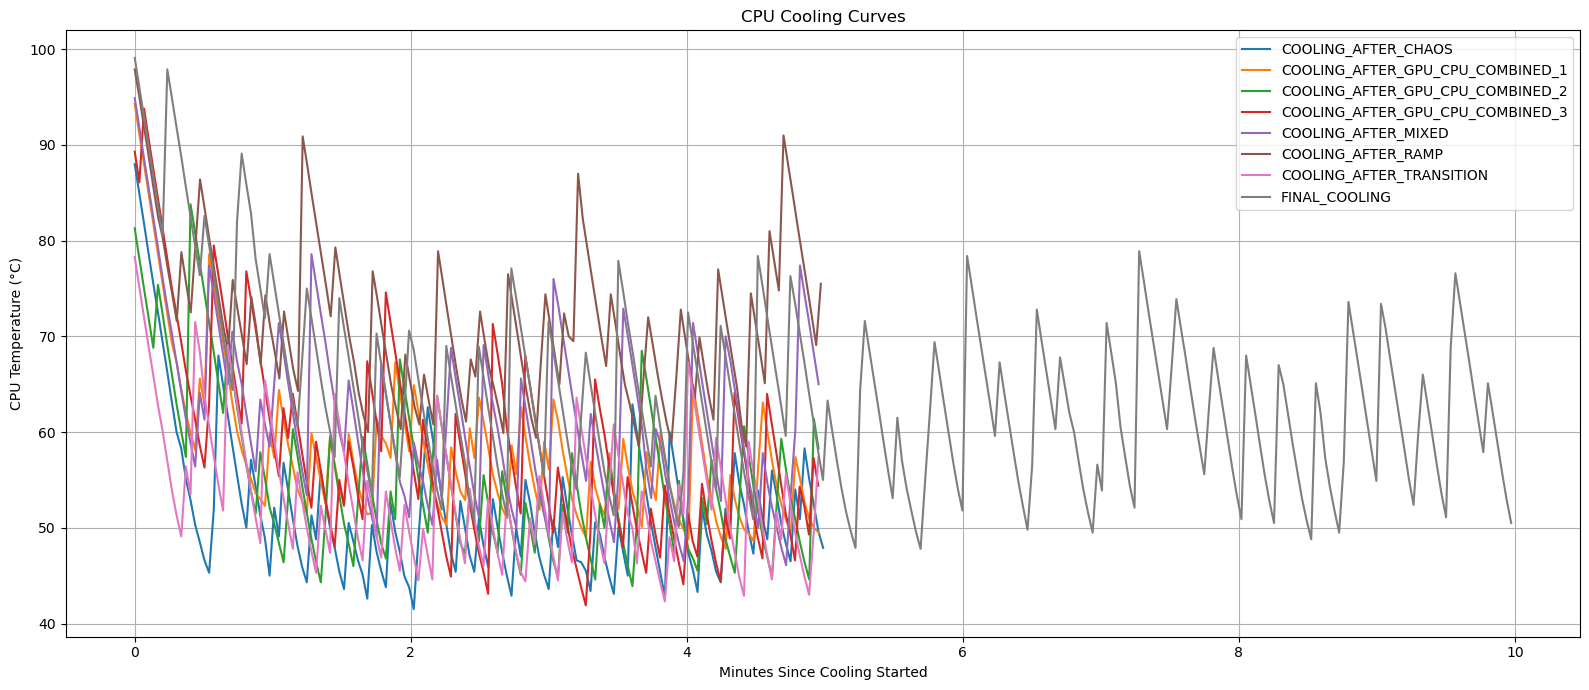

In [51]:
plt.figure(figsize=(16, 7))

for mode, group in cooling.groupby("mode"):

    group = group.sort_values("timestamp").copy()

    elapsed_minutes = (
        group["timestamp"] -
        group["timestamp"].min()
    ).dt.total_seconds() / 60

    plt.plot(
        elapsed_minutes,
        group["cpuTemperature"],
        label=mode
    )

plt.title("CPU Cooling Curves")
plt.xlabel("Minutes Since Cooling Started")
plt.ylabel("CPU Temperature (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [52]:
cooling_summary = []

for mode, group in cooling.groupby("mode"):

    group = group.sort_values("timestamp")

    start_temp = group["cpuTemperature"].iloc[0]
    end_temp = group["cpuTemperature"].iloc[-1]

    duration_minutes = (
        group["timestamp"].iloc[-1] -
        group["timestamp"].iloc[0]
    ).total_seconds() / 60

    temperature_drop = (
        start_temp - end_temp
    )

    cooling_rate = (
        temperature_drop / duration_minutes
        if duration_minutes > 0
        else np.nan
    )

    cooling_summary.append({
        "mode": mode,
        "startTemperature": start_temp,
        "endTemperature": end_temp,
        "temperatureDrop": temperature_drop,
        "durationMinutes": duration_minutes,
        "coolingRatePerMinute": cooling_rate
    })

cooling_summary = pd.DataFrame(
    cooling_summary
)

display(cooling_summary)

,mode,startTemperature,endTemperature,temperatureDrop,durationMinutes,coolingRatePerMinute
0,COOLING_AFTER_CHAOS,88.0,47.9,40.1,4.988051,8.039213
1,COOLING_AFTER_GPU_CPU_COMBINED_1,94.3,49.5,44.8,4.955784,9.039941
2,COOLING_AFTER_GPU_CPU_COMBINED_2,81.3,58.3,23.0,4.954658,4.642096
3,COOLING_AFTER_GPU_CPU_COMBINED_3,89.3,54.4,34.9,4.952653,7.046728
4,COOLING_AFTER_MIXED,94.9,65.0,29.9,4.955394,6.033828
5,COOLING_AFTER_RAMP,97.9,75.5,22.4,4.971588,4.505603
6,COOLING_AFTER_TRANSITION,78.3,57.4,20.9,4.953831,4.218957
7,FINAL_COOLING,99.1,50.5,48.6,9.973539,4.872894


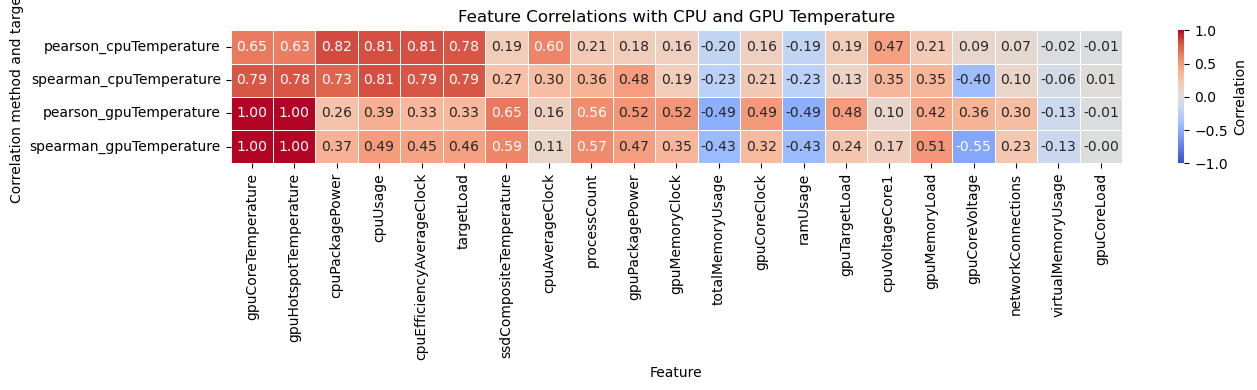

In [ ]:
# Heatmap of all numeric features against CPU and GPU temperature.
heatmap_data = correlation_summary.drop(columns="max_abs_pearson").T
plt.figure(figsize=(max(12, len(heatmap_data.columns) * 0.65), 4))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, linewidths=0.4, cbar_kws={"label": "Correlation"})
plt.title("Feature Correlations with CPU and GPU Temperature")
plt.xlabel("Feature")
plt.ylabel("Correlation method and target")
plt.tight_layout()
plt.show()

In [42]:
# Sort by time
df = merged.sort_values("timestamp").reset_index(drop=True).copy()

# Your data is sampled roughly every 2 seconds
# 20 seconds ≈ 10 rows ahead
HORIZON_STEPS = 10

# Temperature 20 seconds into the future
df["futureTemperature"] = df["cpuTemperature"].shift(-HORIZON_STEPS)

# Exact target used conceptually by your model
df["delta_t"] = (
    df["futureTemperature"] - df["cpuTemperature"]
)

# Remove final rows where future temperature is unavailable
delta_df = df.dropna(subset=["delta_t"]).copy()

print("========== MANAN DELTA T ANALYSIS ==========")
print(delta_df["delta_t"].describe())

print("\nPercentage |Delta T| <= 1°C:")
print((delta_df["delta_t"].abs() <= 1).mean() * 100, "%")

print("\nPercentage Delta T == 0°C:")
print((delta_df["delta_t"] == 0).mean() * 100, "%")

print("\nPercentage Delta T > 4°C:")
print((delta_df["delta_t"] > 4).mean() * 100, "%")

print("\nMost common Delta T values:")
print(delta_df["delta_t"].value_counts().head(15))

========== MANAN DELTA T ANALYSIS ==========
count    14802.000000
mean         0.000041
std          6.193981
min        -33.800000
25%         -0.500000
50%          0.000000
75%          0.500000
max         40.600000
Name: delta_t, dtype: float64

Percentage |Delta T| <= 1°C:
61.451155249290636 %

Percentage Delta T == 0°C:
25.787055803269826 %

Percentage Delta T > 4°C:
7.57330090528307 %

Most common Delta T values:
delta_t
 0.0    3817
-0.1     426
-0.2     403
 0.1     396
-0.1     376
 0.2     254
 0.1     245
 0.5     241
-0.5     230
 1.0     158
 0.4     146
 0.3     144
-0.3     144
-1.0     133
 1.5     127
Name: count, dtype: int64


In [43]:
mode_analysis = (
    delta_df
    .groupby("mode")["delta_t"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
    .sort_values("count", ascending=False)
)

display(mode_analysis)

,count,mean,median,std,min,max
mode,,,,,,
MIXED,4377,0.046676,0.00,6.338376,-32.9,36.6
GPU_CPU_COMBINED,2217,0.088002,0.00,5.452790,-28.3,31.2
CHAOS,2192,-0.110082,0.00,7.942790,-33.8,37.4
RAMP,2192,0.038230,0.00,4.093190,-33.5,21.8
TRANSITION,2187,0.063740,0.00,6.707216,-33.2,40.6
FINAL_COOLING,296,-0.304730,0.10,3.544312,-14.4,9.9
UNASSIGNED,242,-0.166529,0.05,3.740548,-15.2,16.0
COOLING_AFTER_GPU_CPU_COMBINED_1,149,0.617450,-0.60,9.968082,-20.5,37.7
COOLING_AFTER_GPU_CPU_COMBINED_3,149,-1.689262,-1.20,3.997113,-16.5,8.8


In [44]:
for mode, group in delta_df.groupby("mode"):

    if len(group) < 10:
        continue

    print(f"\n========== {mode} ==========")
    print("Samples:", len(group))
    print("Mean Delta T:", group["delta_t"].mean())
    print("Median Delta T:", group["delta_t"].median())

    print(
        "% |Delta T| <= 1°C:",
        (group["delta_t"].abs() <= 1).mean() * 100
    )

    print(
        "% Delta T > 4°C:",
        (group["delta_t"] > 4).mean() * 100
    )


========== CHAOS ==========
Samples: 2192
Mean Delta T: -0.11008211678832118
Median Delta T: 0.0
% |Delta T| <= 1°C: 60.4470802919708
% Delta T > 4°C: 8.074817518248176

========== COOLING_AFTER_CHAOS ==========
Samples: 148
Mean Delta T: -0.9054054054054054
Median Delta T: -0.3999999999999986
% |Delta T| <= 1°C: 45.94594594594595
% Delta T > 4°C: 7.4324324324324325

========== COOLING_AFTER_GPU_CPU_COMBINED_1 ==========
Samples: 149
Mean Delta T: 0.6174496644295304
Median Delta T: -0.6000000000000014
% |Delta T| <= 1°C: 37.58389261744966
% Delta T > 4°C: 10.06711409395973

========== COOLING_AFTER_GPU_CPU_COMBINED_2 ==========
Samples: 148
Mean Delta T: -0.6391891891891891
Median Delta T: -0.29999999999999716
% |Delta T| <= 1°C: 52.702702702702695
% Delta T > 4°C: 4.72972972972973

========== COOLING_AFTER_GPU_CPU_COMBINED_3 ==========
Samples: 149
Mean Delta T: -1.689261744966443
Median Delta T: -1.2000000000000028
% |Delta T| <= 1°C: 32.21476510067114
% Delta T > 4°C: 6.04026845637

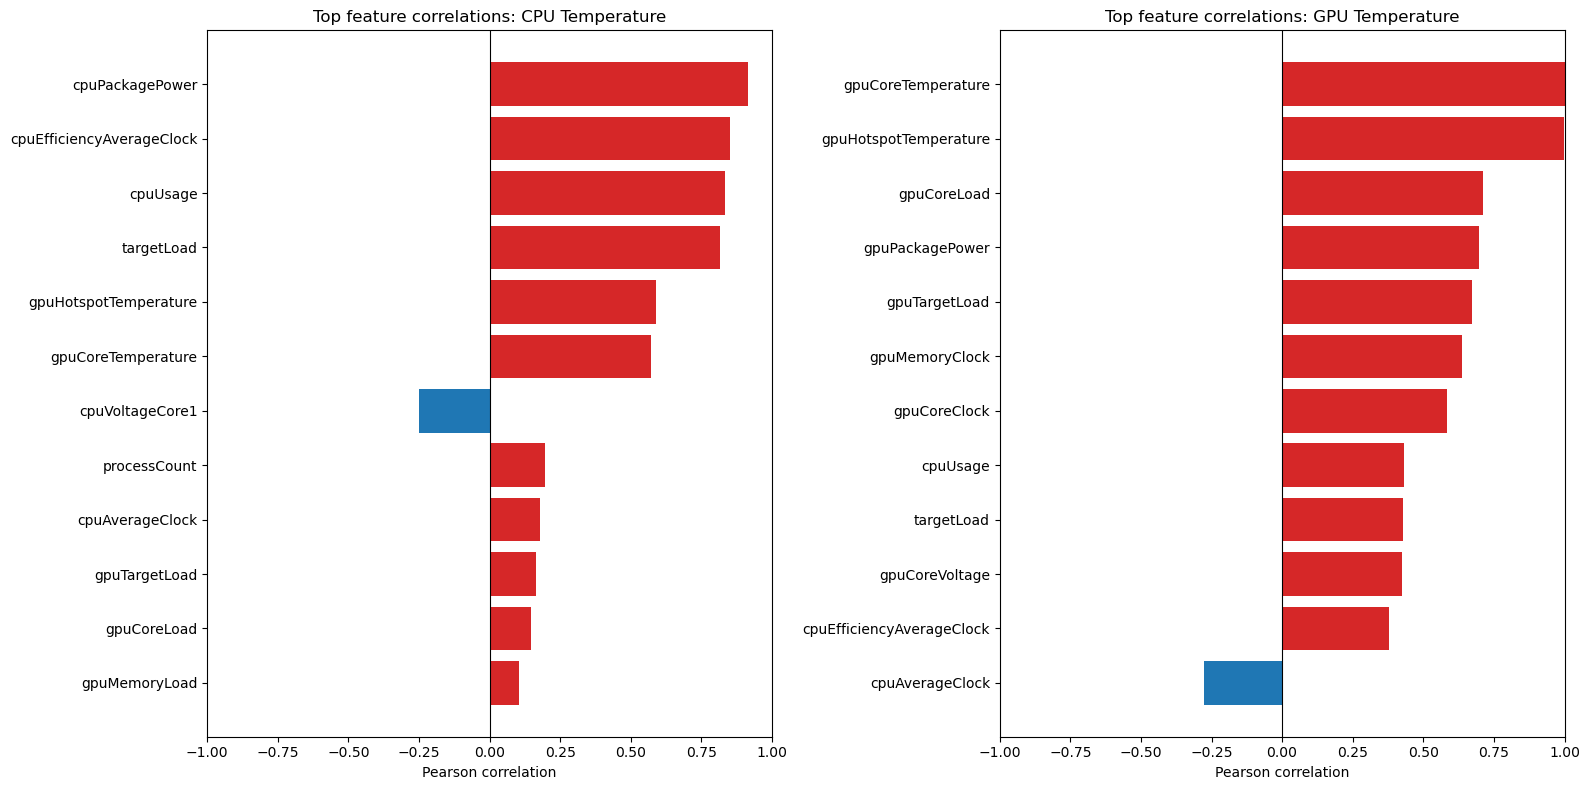

In [45]:
# Rank the strongest Pearson relationships for each temperature target.
ranked = correlation_summary.drop(columns="max_abs_pearson").copy()
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=False)

for ax, column, title in [
    (axes[0], "pearson_cpuTemperature", "CPU Temperature"),
    (axes[1], "pearson_gpuTemperature", "GPU Temperature"),
]:
    values = ranked[column].dropna().sort_values(key=lambda x: x.abs()).tail(12)
    colors = np.where(values >= 0, "tab:red", "tab:blue")
    ax.barh(values.index, values.values, color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlim(-1, 1)
    ax.set_title(f"Top feature correlations: {title}")
    ax.set_xlabel("Pearson correlation")

plt.tight_layout()
plt.show()

GPU_CPU_COMBINED workload samples: 2217


,cpuTemperature,gpuTemperature
targetLoad,0.669,0.167
gpuTargetLoad,0.487,0.795
cpuUsage,0.705,0.234
cpuPackagePower,0.678,-0.208
gpuCoreLoad,0.285,0.873
gpuPackagePower,0.198,0.852
gpuCoreClock,0.224,0.817
gpuMemoryLoad,0.083,0.185


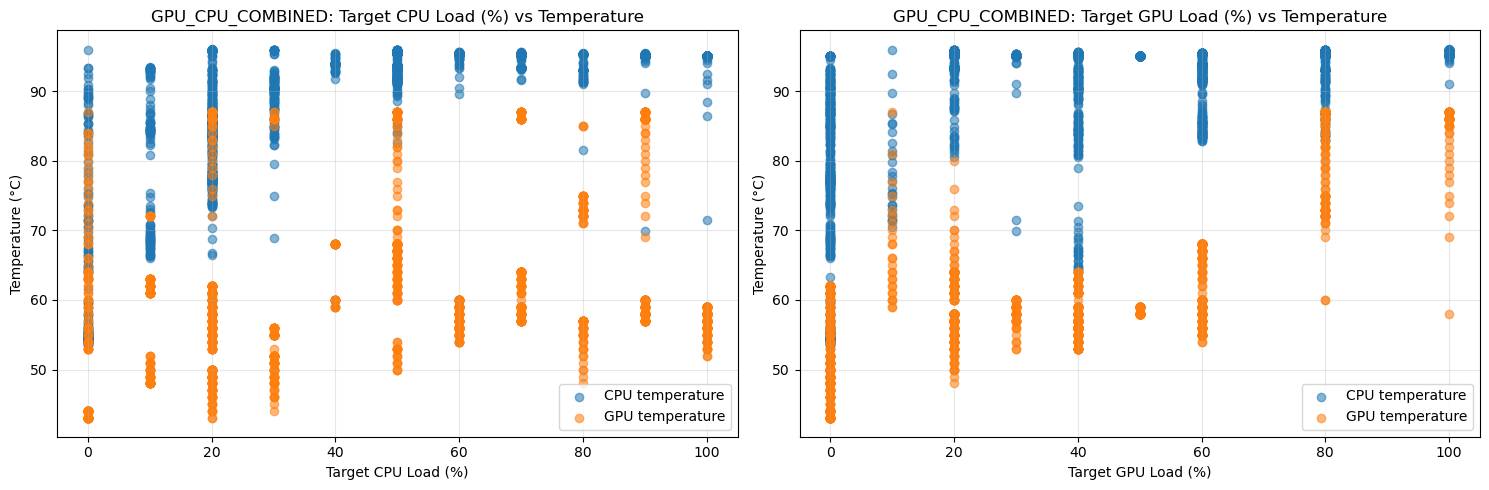

In [46]:
# GPU_CPU_COMBINED is analysed separately because gpuTargetLoad is only set there.
gpu_cpu_combined = merged[
    (merged["mode"] == "GPU_CPU_COMBINED") &
    (merged["eventType"] == "WORKLOAD_STEP")
].copy()

combined_features = [
    "targetLoad", "gpuTargetLoad", "cpuUsage", "cpuPackagePower",
    "gpuCoreLoad", "gpuPackagePower", "gpuCoreClock", "gpuMemoryLoad"
]
combined_features = [col for col in combined_features if col in gpu_cpu_combined]
combined_correlation = gpu_cpu_combined[
    combined_features + temperature_targets
].corr(method="pearson").loc[combined_features, temperature_targets]

print(f"GPU_CPU_COMBINED workload samples: {len(gpu_cpu_combined)}")
display(combined_correlation.round(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, x_col, x_label in [
    (axes[0], "targetLoad", "Target CPU Load (%)"),
    (axes[1], "gpuTargetLoad", "Target GPU Load (%)"),
]:
    scatter_data = gpu_cpu_combined.dropna(subset=[x_col])
    ax.scatter(scatter_data[x_col], scatter_data["cpuTemperature"], alpha=0.55,
               label="CPU temperature")
    ax.scatter(scatter_data[x_col], scatter_data["gpuTemperature"], alpha=0.55,
               label="GPU temperature")
    ax.set_title(f"GPU_CPU_COMBINED: {x_label} vs Temperature")
    ax.set_xlabel(x_label)
    ax.set_ylabel("Temperature (°C)")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# Correlation quantifies association, not causation; interpret it with the
# workload mode and the time-series plots above.